# Chinook Database Analysis

In [1]:
# importing libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# connecting to database
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

## 1. Revenue by Country

In [2]:
# running query and building DataFrame
query = """
SELECT billingcountry, SUM(total) AS Revenue
FROM invoice
GROUP BY billingcountry
ORDER BY Revenue DESC;
"""
    
df_country_revenue = pd.read_sql_query(query, conn)
df_country_revenue.head(10)

,BillingCountry,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


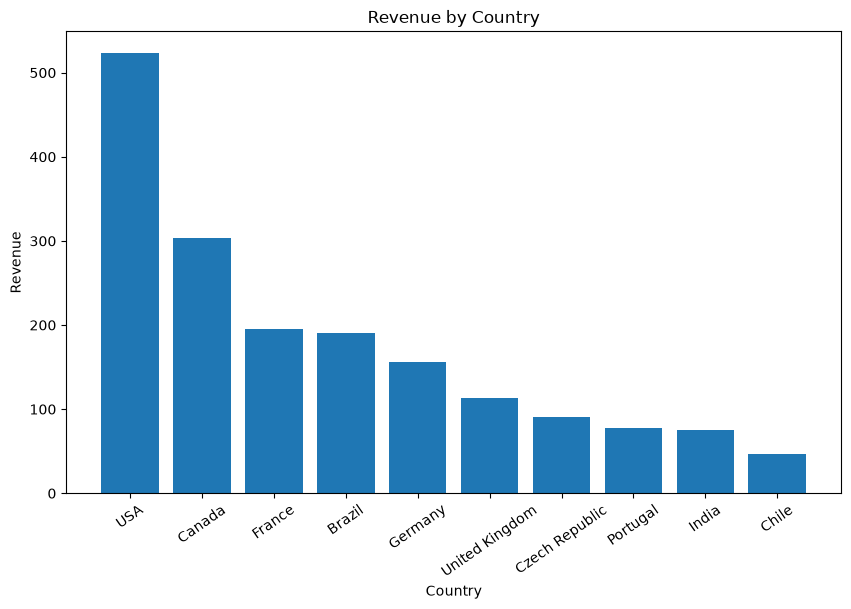

In [3]:
# creating visualization
top_countries = df_country_revenue.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_countries["BillingCountry"], top_countries["Revenue"])
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=35)

plt.show()

## 2. Top 10 Customers

In [4]:
# running query and building DataFrame
query = """
SELECT customerid, firstname || ' ' || lastname AS CustomerName, SUM(total) AS TotalSpending
FROM customer AS c
INNER JOIN invoice AS iv
USING(customerid)
GROUP BY customerid
ORDER BY TotalSpending DESC
LIMIT 10;
"""

df_top_customers = pd.read_sql_query(query, conn)
df_top_customers.head(10)

,CustomerId,CustomerName,TotalSpending
0,6,Helena Holý,49.62
1,26,Richard Cunningham,47.62
2,57,Luis Rojas,46.62
3,45,Ladislav Kovács,45.62
4,46,Hugh O'Reilly,45.62
5,24,Frank Ralston,43.62
6,28,Julia Barnett,43.62
7,37,Fynn Zimmermann,43.62
8,7,Astrid Gruber,42.62
9,25,Victor Stevens,42.62


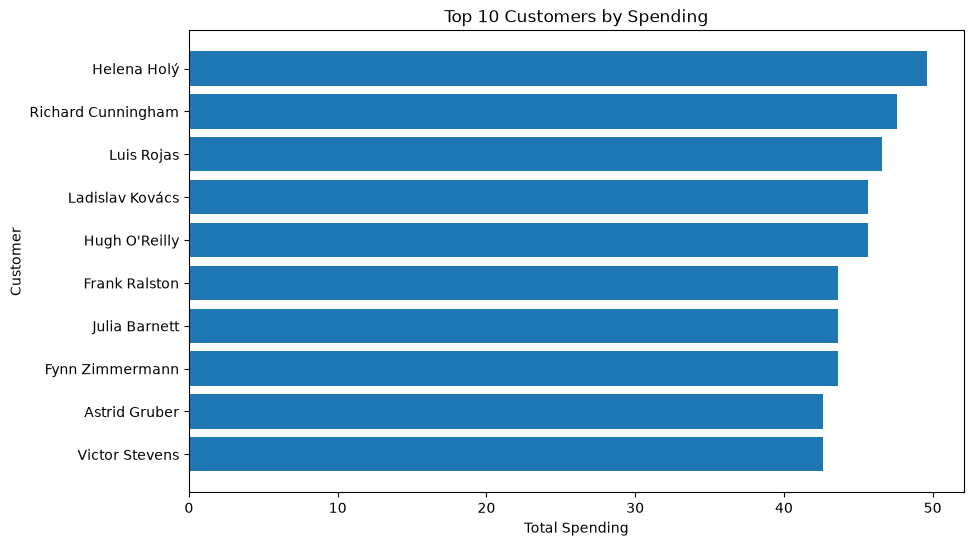

In [5]:
# creating visualization
plt.figure(figsize=(10, 6))
plt.barh(df_top_customers["CustomerName"], df_top_customers["TotalSpending"])
plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer")

# display highest spender at the top
plt.gca().invert_yaxis()

plt.show()

## 3. Revenue by Genre

In [6]:
# running query and building DataFrame
query = """
SELECT g.name AS GenreName, SUM(ivl.unitprice * quantity) AS Revenue
FROM invoiceline AS ivl
INNER JOIN track AS t USING(trackid)
INNER JOIN genre AS g USING(genreid)
GROUP BY g.name
ORDER BY Revenue DESC;
"""

df_genre_revenue = pd.read_sql_query(query, conn)
df_genre_revenue.head(10)

,GenreName,Revenue
0,Rock,826.65
1,Latin,382.14
2,Metal,261.36
3,Alternative & Punk,241.56
4,TV Shows,93.53
5,Jazz,79.20
6,Blues,60.39
7,Drama,57.71
8,R&B/Soul,40.59
9,Classical,40.59


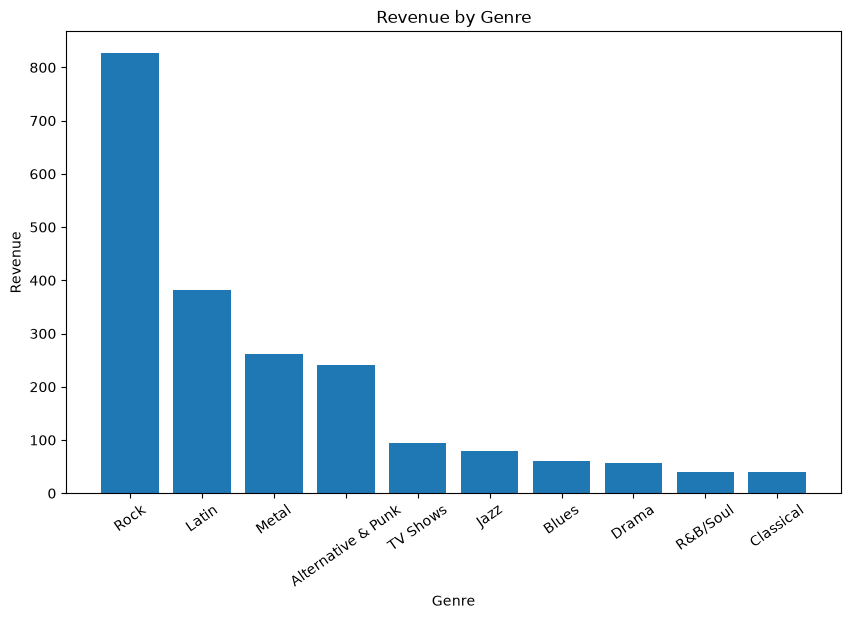

In [7]:
# creating visualization
top_genres = df_genre_revenue.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_genres["GenreName"], top_genres["Revenue"])
plt.title("Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue")
plt.xticks(rotation=35)

plt.show()

## 4. Top Artists

In [8]:
# running query and building DataFrame
query = """
SELECT ar.name AS ArtistName, SUM(ivl.unitprice * quantity) AS Revenue
FROM invoiceline AS ivl
INNER JOIN track AS t USING(trackid)
INNER JOIN album AS al USING(albumid)
INNER JOIN artist AS ar USING(artistid)
GROUP BY ar.name
ORDER BY Revenue DESC;
"""

df_artist_revenue = pd.read_sql_query(query, conn)
df_artist_revenue.head(10)

,ArtistName,Revenue
0,Iron Maiden,138.60
1,U2,105.93
2,Metallica,90.09
3,Led Zeppelin,86.13
4,Lost,81.59
5,The Office,49.75
6,Os Paralamas Do Sucesso,44.55
7,Deep Purple,43.56
8,Faith No More,41.58
9,Eric Clapton,39.60


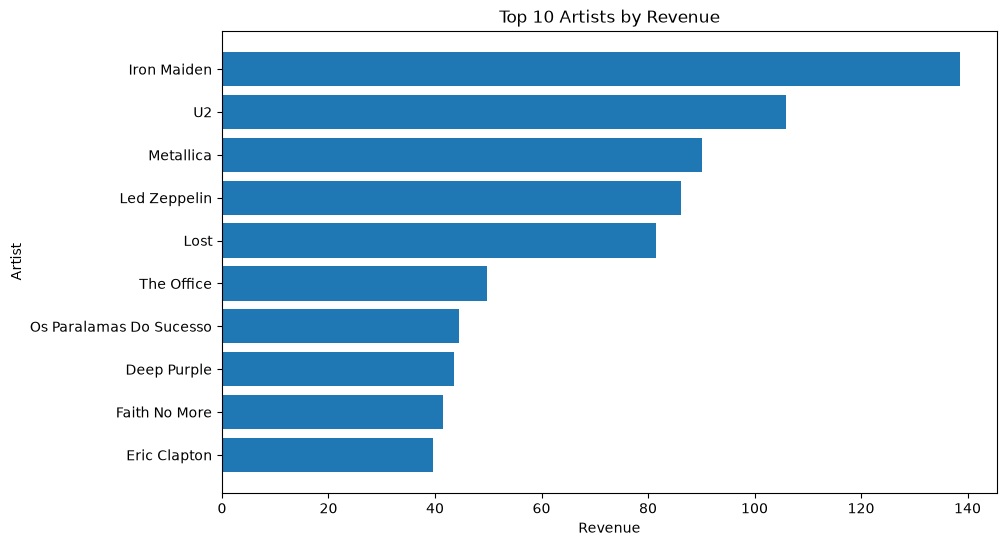

In [9]:
# creating visualization
top_artists = df_artist_revenue.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_artists["ArtistName"], top_artists["Revenue"])
plt.title("Top 10 Artists by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Artist")

# display highest earning artist at the top
plt.gca().invert_yaxis()

plt.show()

## 5. Monthly Sales Trend

In [10]:
# running query and building DataFrame
query = """
SELECT strftime('%Y-%m', invoicedate) AS Month, SUM(total) AS Revenue
FROM invoice
GROUP BY Month
ORDER BY Month;
"""

df_monthly_revenue = pd.read_sql_query(query, conn)
df_monthly_revenue.head(10)

,Month,Revenue
0,2021-01,35.64
1,2021-02,37.62
2,2021-03,37.62
3,2021-04,37.62
4,2021-05,37.62
5,2021-06,37.62
6,2021-07,37.62
7,2021-08,37.62
8,2021-09,37.62
9,2021-10,37.62


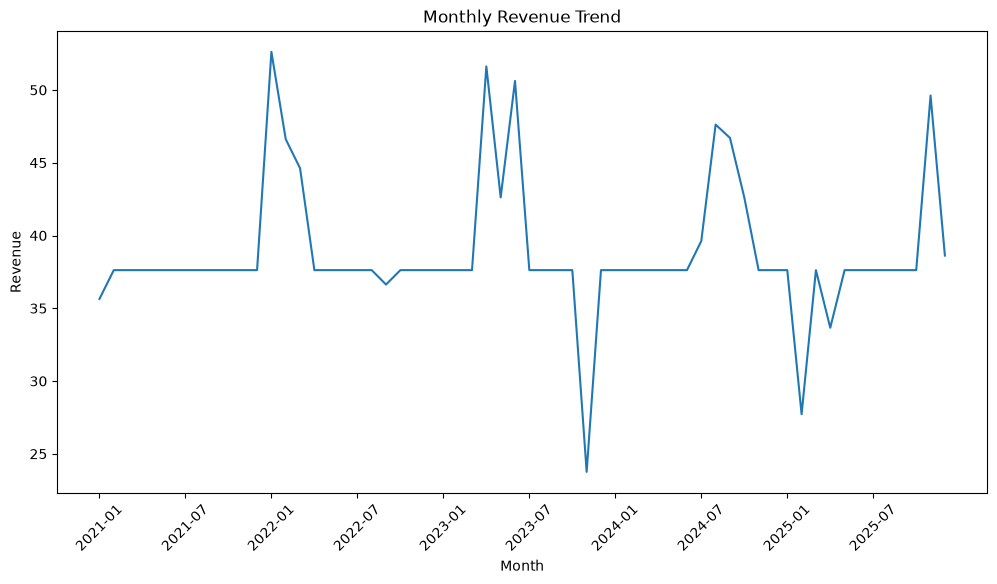

In [11]:
# creating visualization
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_revenue["Month"], df_monthly_revenue["Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

# show every 6th label to keep the axis clean
ticks = range(0, len(df_monthly_revenue), 6)
plt.xticks(ticks, df_monthly_revenue["Month"].iloc[ticks], rotation=45)

plt.show()

## 6. Customer Distribution by Country

In [12]:
# running query and building DataFrame
query = """
SELECT country, COUNT(*) AS CustomerCount
FROM customer
GROUP BY country
ORDER BY CustomerCount DESC;
"""

df_customer_country = pd.read_sql_query(query, conn)
df_customer_country.head(10)

,Country,CustomerCount
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


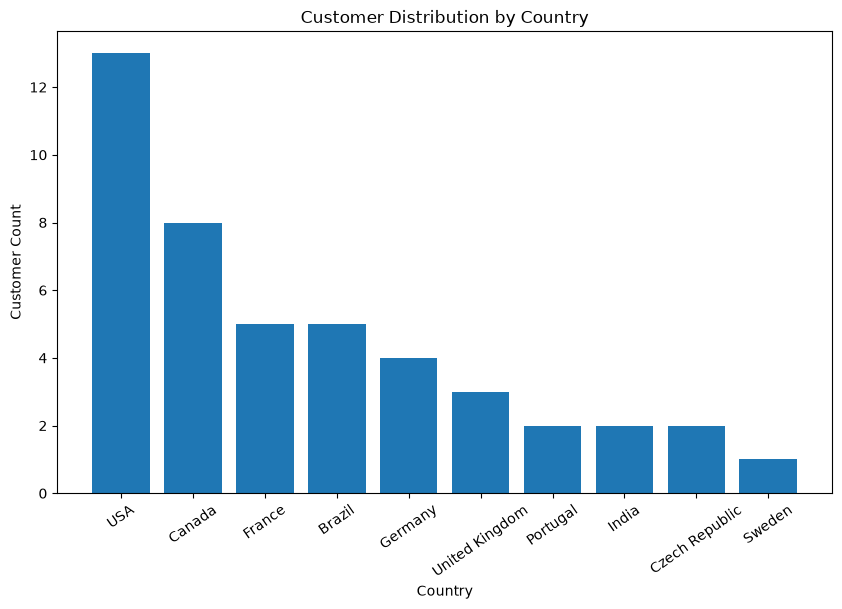

In [13]:
# creating visualization
top_customer_countries = df_customer_country.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_customer_countries["Country"], top_customer_countries["CustomerCount"])
plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Customer Count")
plt.xticks(rotation=35)

plt.show()

## 7. Yearly Sales Trend

In [14]:
# running query and building DataFrame
query = """
SELECT strftime('%Y', invoicedate) AS Year, SUM(total) AS Revenue
FROM invoice
GROUP BY Year
ORDER BY Year;
"""

df_yearly_revenue = pd.read_sql_query(query, conn)
df_yearly_revenue.head(10)

,Year,Revenue
0,2021,449.46
1,2022,481.45
2,2023,469.58
3,2024,477.53
4,2025,450.58


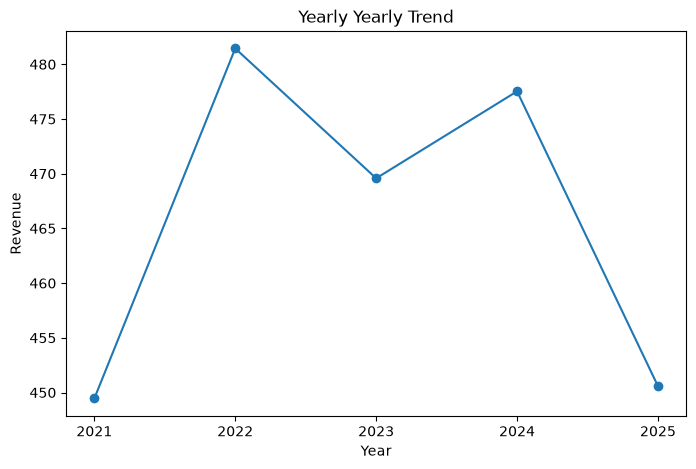

In [15]:
# creating visualization
plt.figure(figsize=(8, 5))
plt.plot(df_yearly_revenue["Year"], df_yearly_revenue["Revenue"], marker="o")
plt.title("Yearly Yearly Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

In [16]:
conn.close()